# Model Training & Evaluation
## Portal Pelaporan Tindak Kriminal Terpadu



## 0. Install Dependencies

In [1]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================

import subprocess
import sys

packages = [
    "mlflow",
    "scikit-learn",
    "pandas",
    "numpy",
    "pycaret[classification]",
    "optuna",
    "xgboost",
    "lightgbm",
    "matplotlib",
    "seaborn",
    "joblib",
    "PySastrawi",
]

for pkg in packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "-q"]
    )

print("✅ Semua dependency terinstall")

✅ Semua dependency terinstall


## 1. Import & Konfigurasi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn
import warnings
import os
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
matplotlib.use('Agg')

# ── Path config ───────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
ROOT = NOTEBOOK_DIR
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA_PATH  = ROOT / "data" / "dataset_siap_training.csv"
MODEL_DIR  = ROOT / "backend" / "ml" / "models"
DOCS_DIR   = ROOT / "docs"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT      : {ROOT}")
print(f"DATA_PATH : {DATA_PATH}")
print(f"Exists    : {DATA_PATH.exists()}")


ROOT      : C:\
DATA_PATH : C:\data\dataset_siap_training.csv
Exists    : True


## 2. Load & Split Data

In [3]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(DATA_PATH)

print(f"Total dataset : {len(df):,} rows")

# ============================================================
# PISAH DATA REAL & SYNTHETIC
# ============================================================

df_real = df[df["is_synthetic"] == "No"].copy()

df_synthetic = df[df["is_synthetic"] == "Yes"].copy()

print(f"Data real     : {len(df_real):,} rows")
print(f"Data sintetis : {len(df_synthetic):,} rows")

Total dataset : 3,771 rows
Data real     : 2,413 rows
Data sintetis : 1,358 rows


In [4]:
# ============================================================
# DATA CLEANING TAMBAHAN
# ============================================================

# hapus duplicate text
df_real = df_real.drop_duplicates(
    subset=["deskripsi_bersih"]
)

# hapus text terlalu pendek
df_real = df_real[
    df_real["deskripsi_bersih"].str.len() > 15
]

# hapus label kosong
df_real = df_real.dropna(
    subset=["label_urgensi"]
)

print("✅ Cleaning selesai")
print(f"Total data real bersih: {len(df_real):,}")

print("\nDistribusi label:")
print(df_real["label_urgensi"].value_counts())

✅ Cleaning selesai
Total data real bersih: 2,413

Distribusi label:
label_urgensi
Tinggi    1257
Sedang     986
Rendah     170
Name: count, dtype: int64


In [5]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_real = df_real["deskripsi_bersih"].fillna("").values

y_real = df_real["label_urgensi"].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_real,
    y_real,
    test_size=0.2,
    random_state=42,
    stratify=y_real
)

# ============================================================
# TAMBAHKAN DATA SYNTHETIC KE TRAINING SAJA
# ============================================================

X_train_raw = np.concatenate([
    X_train_raw,
    df_synthetic["deskripsi_bersih"].fillna("").values
])

y_train = np.concatenate([
    y_train,
    df_synthetic["label_urgensi"].values
])

print(f"Train set : {len(X_train_raw):,}")
print(f"Test set  : {len(X_test_raw):,}")

Train set : 3,288
Test set  : 483


In [6]:
# ============================================================
# TF-IDF VECTORIZER
# ============================================================

vectorizer = TfidfVectorizer(

    max_features=15000,

    ngram_range=(1, 3),

    min_df=2,

    max_df=0.95,

    sublinear_tf=True,

    strip_accents='unicode'
)

X_train = vectorizer.fit_transform(X_train_raw)

X_test = vectorizer.transform(X_test_raw)

print("✅ TF-IDF selesai")
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")

✅ TF-IDF selesai
X_train shape : (3288, 15000)
X_test shape  : (483, 15000)
Vocabulary size: 15,000


## 3. PyCaret — Perbandingan Model

PyCaret digunakan untuk membandingkan 15+ algoritma secara otomatis
dan memberikan **justifikasi ilmiah** dalam memilih 3 model baseline.

> Bukan memilih model secara subjektif, melainkan berbasis data.


In [7]:
from pycaret.classification import setup, compare_models, pull

# PyCaret bekerja dengan DataFrame — gunakan data train
df_pycaret = pd.DataFrame({
    'teks'   : X_train_raw,
    'label'  : y_train
})

print("Setup PyCaret...")
clf_setup = setup(
    data            = df_pycaret,
    target          = 'label',
    train_size      = 0.8,
    fold            = 5,
    session_id      = 42,
    text_features   = ['teks'],
    verbose         = False,
)
print("✅ Setup selesai")


Setup PyCaret...
✅ Setup selesai


In [8]:
print("Membandingkan semua model (estimasi 5-10 menit)...")
best_models = compare_models(
    n_select     = 3,       # ambil top 3
    sort         = 'F1',    # sort berdasarkan F1 (lebih fair untuk multiclass)
    verbose      = True,
    exclude      = ['catboost'],  # exclude karena butuh install terpisah
)

# Tampilkan hasil perbandingan
results_df = pull()
print("\n=== HASIL PERBANDINGAN MODEL ===")
print(results_df[['Model', 'Accuracy', 'F1', 'Prec.', 'Recall', 'TT (Sec)']].to_string())

# Identifikasi top 3
print("\n✅ Top 3 model yang dipilih untuk baseline:")
for i, m in enumerate(best_models):
    print(f"  {i+1}. {type(m).__name__}")


Membandingkan semua model (estimasi 5-10 menit)...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9468,0.9931,0.9468,0.9471,0.9468,0.9199,0.9200,7.7940
svm,SVM - Linear Kernel,0.9403,0.0000,0.9403,0.9406,0.9401,0.9101,0.9104,1.2320
ridge,Ridge Classifier,0.9399,0.0000,0.9399,0.9401,0.9397,0.9095,0.9097,2.4380
xgboost,Extreme Gradient Boosting,0.9388,0.9913,0.9388,0.9393,0.9389,0.9079,0.9080,23.3040
lr,Logistic Regression,0.9331,0.0000,0.9331,0.9334,0.9330,0.8992,0.8995,4.7840
et,Extra Trees Classifier,0.9327,0.9897,0.9327,0.9335,0.9329,0.8987,0.8989,2.6400
gbc,Gradient Boosting Classifier,0.9319,0.0000,0.9319,0.9322,0.9319,0.8975,0.8976,27.3080
rf,Random Forest Classifier,0.9125,0.9836,0.9125,0.9132,0.9128,0.8684,0.8685,1.4180
nb,Naive Bayes,0.8871,0.9169,0.8871,0.8876,0.8868,0.8299,0.8304,1.2240
knn,K Neighbors Classifier,0.8856,0.9701,0.8856,0.8869,0.8832,0.8269,0.8298,2.6520



=== HASIL PERBANDINGAN MODEL ===
                                    Model  Accuracy      F1   Prec.  Recall  TT (Sec)
lightgbm  Light Gradient Boosting Machine    0.9468  0.9468  0.9471  0.9468     7.794
svm                   SVM - Linear Kernel    0.9403  0.9401  0.9406  0.9403     1.232
ridge                    Ridge Classifier    0.9399  0.9397  0.9401  0.9399     2.438
xgboost         Extreme Gradient Boosting    0.9388  0.9389  0.9393  0.9388    23.304
lr                    Logistic Regression    0.9331  0.9330  0.9334  0.9331     4.784
et                 Extra Trees Classifier    0.9327  0.9329  0.9335  0.9327     2.640
gbc          Gradient Boosting Classifier    0.9319  0.9319  0.9322  0.9319    27.308
rf               Random Forest Classifier    0.9125  0.9128  0.9132  0.9125     1.418
nb                            Naive Bayes    0.8871  0.8868  0.8876  0.8871     1.224
knn                K Neighbors Classifier    0.8856  0.8832  0.8869  0.8856     2.652
ada                 

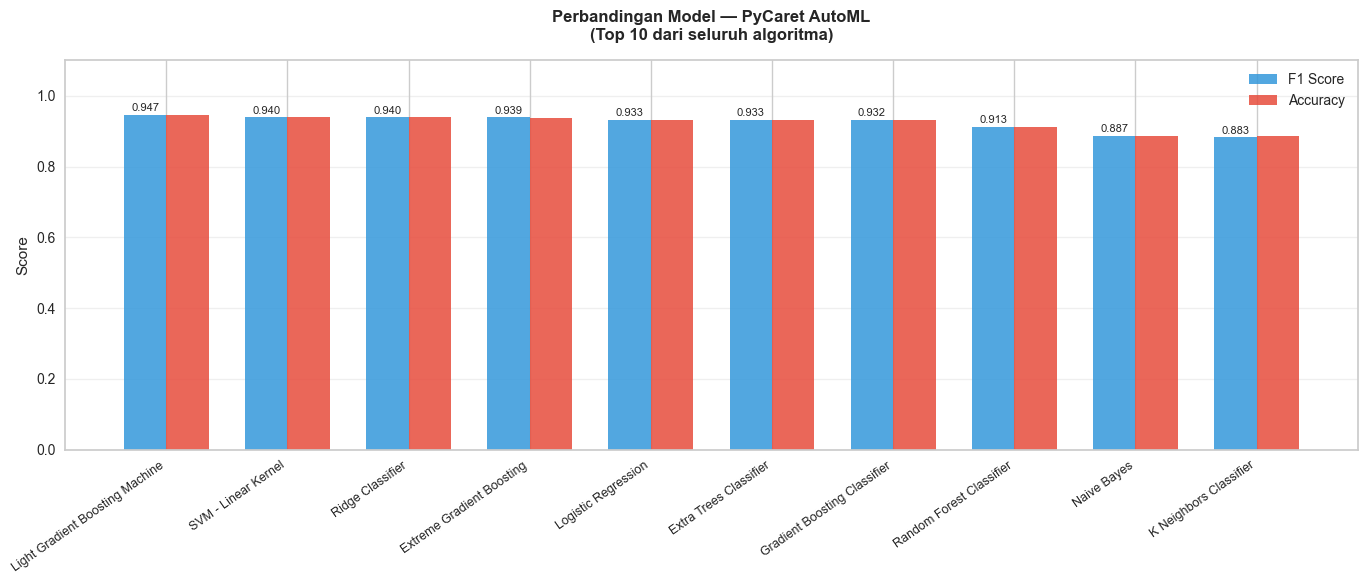

✅ Plot disimpan ke docs/08_pycaret_comparison.png


In [9]:
# ── Visualisasi hasil PyCaret ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

top_n = min(10, len(results_df))
models_viz  = results_df['Model'].head(top_n).values
f1_scores   = results_df['F1'].head(top_n).values
acc_scores  = results_df['Accuracy'].head(top_n).values

x = np.arange(top_n)
w = 0.35
bars1 = ax.bar(x - w/2, f1_scores,   w, label='F1 Score',  color='#3498db', alpha=0.85)
bars2 = ax.bar(x + w/2, acc_scores,  w, label='Accuracy',  color='#e74c3c', alpha=0.85)

ax.set_title(
    'Perbandingan Model — PyCaret AutoML\n(Top 10 dari seluruh algoritma)',
    fontweight='bold',
    pad=15
)
ax.set_xticks(x)
ax.set_xticklabels(models_viz, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(DOCS_DIR / '08_pycaret_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot disimpan ke docs/08_pycaret_comparison.png")


## 4. Training Baseline Model + MLflow Tracking

Training ulang top 3 model dari PyCaret dengan MLflow tracking penuh.
Setiap model dicatat sebagai satu **run** di MLflow.


In [12]:
# ============================================================
# BASELINE MODELS
# ============================================================
from lightgbm import LGBMClassifier
from sklearn.linear_model import RidgeClassifier

BASELINE_MODELS = {

    "LGBMClassifier": LGBMClassifier(

        n_estimators=300,

        learning_rate=0.05,

        class_weight='balanced',

        random_state=42,

        n_jobs=-1
    ),

    "LinearSVC": LinearSVC(

        C=1.5,

        class_weight='balanced',

        max_iter=8000,

        random_state=42
    ),

    "RidgeClassifier": RidgeClassifier(

        alpha=1.0,

        class_weight='balanced',

        random_state=42
    ),
}


def evaluate_model(model, X_tr, y_tr, X_te, y_te):

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)

    metrics = {

        "accuracy": accuracy_score(
            y_te,
            y_pred
        ),

        "f1_macro": f1_score(
            y_te,
            y_pred,
            average='macro'
        ),

        "f1_weighted": f1_score(
            y_te,
            y_pred,
            average='weighted'
        ),

        "precision_macro": precision_score(
            y_te,
            y_pred,
            average='macro',
            zero_division=0
        ),

        "recall_macro": recall_score(
            y_te,
            y_pred,
            average='macro',
            zero_division=0
        ),
    }

    return metrics, y_pred

print("✅ Baseline model siap")

✅ Baseline model siap


In [18]:
# ── TF-IDF Preparation ───────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# FIT ke TRAIN SET
X_train_tfidf = vectorizer.fit_transform(X_train_raw)

# TRANSFORM TEST SET
X_test_tfidf = vectorizer.transform(X_test_raw)

print("✅ TF-IDF berhasil dibuat")
print()

print(f"Train TF-IDF shape : {X_train_tfidf.shape}")
print(f"Test TF-IDF shape  : {X_test_tfidf.shape}")
print()

print(f"Vocabulary size    : {len(vectorizer.vocabulary_):,}")
print(f"Max features       : {vectorizer.max_features}")
print(f"Ngram range        : {vectorizer.ngram_range}")

✅ TF-IDF berhasil dibuat

Train TF-IDF shape : (3288, 5000)
Test TF-IDF shape  : (483, 5000)

Vocabulary size    : 5,000
Max features       : 5000
Ngram range        : (1, 2)


In [13]:
# ============================================================
# SETUP MLFLOW
# ============================================================

mlflow.set_tracking_uri("file:./mlruns")

mlflow.set_experiment(
    "PBL_Klasifikasi_Urgensi"
)

print("✅ MLflow setup selesai")

Traceback (most recent call last):
  File "C:\Users\user\AppData\Roaming\Python\Python310\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "C:\Users\user\AppData\Roaming\Python\Python310\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "C:\Users\user\AppData\Roaming\Python\Python310\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "C:\Users\user\AppData\Roaming\Python\Python310\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "C:\Users\user\AppData\Roaming\Python\Python310\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    raise MissingConfigException(f"Yaml file '{file_path}' does n

✅ MLflow setup selesai


In [14]:
# ============================================================
# TRAIN BASELINE MODELS
# ============================================================

baseline_results = {}

for model_name, model in BASELINE_MODELS.items():

    print(f"\nTraining {model_name}...")

    with mlflow.start_run(
        run_name=f"baseline_{model_name}"
    ):

        # ====================================================
        # LOG PARAMS
        # ====================================================

        mlflow.log_params(
            model.get_params()
        )

        mlflow.log_param(
            "vectorizer_max_features",
            vectorizer.max_features
        )

        mlflow.log_param(
            "vectorizer_ngram_range",
            str(vectorizer.ngram_range)
        )

        mlflow.log_param(
            "train_size",
            X_train.shape[0]
        )

        mlflow.log_param(
            "test_size",
            X_test.shape[0]
        )

        # ====================================================
        # TRAIN & EVALUATE
        # ====================================================

        metrics, y_pred = evaluate_model(
            model,
            X_train,
            y_train,
            X_test,
            y_test
        )

        # ====================================================
        # LOG METRICS
        # ====================================================

        mlflow.log_metrics(metrics)

        # ====================================================
        # SAVE MODEL TO MLFLOW
        # ====================================================

        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model"
        )

        run_id = mlflow.active_run().info.run_id

        baseline_results[model_name] = {

            **metrics,

            "model": model,

            "y_pred": y_pred,

            "run_id": run_id
        }

        print(f"Accuracy   : {metrics['accuracy']:.4f}")
        print(f"F1 Macro   : {metrics['f1_macro']:.4f}")
        print(f"Run ID     : {run_id[:8]}")

print("\n✅ Semua baseline selesai")


Training LGBMClassifier...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.149552 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 125152
[LightGBM] [Info] Number of data points in the train set: 3288, number of used features: 5323
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


2026/05/14 08:58:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 08:58:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy   : 0.9110
F1 Macro   : 0.8526
Run ID     : 454d576c

Training LinearSVC...


2026/05/14 08:58:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 08:58:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy   : 0.8841
F1 Macro   : 0.8263
Run ID     : 5ee3ce81

Training RidgeClassifier...


2026/05/14 08:58:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 08:58:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy   : 0.8861
F1 Macro   : 0.8367
Run ID     : 71ea7d0c

✅ Semua baseline selesai


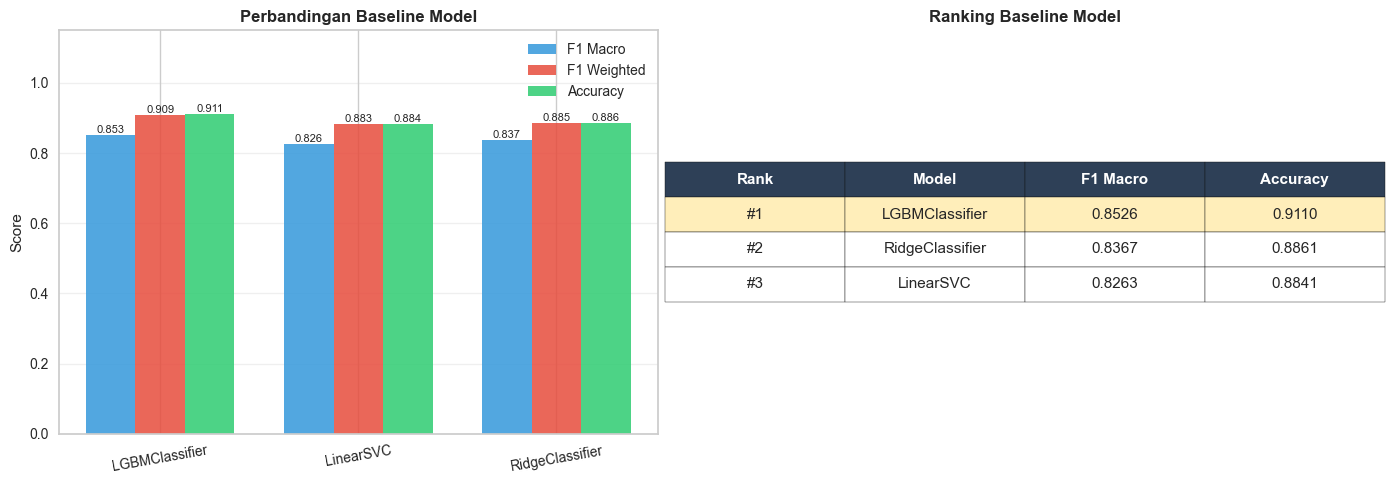


🏆 Model terbaik: LGBMClassifier (F1 Macro: 0.8526)
   → Model ini akan di-tuning dengan Optuna


In [16]:
# ── Visualisasi perbandingan baseline ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(baseline_results.keys())
metrics_to_plot = {
    'F1 Macro'   : [baseline_results[m]['f1_macro']    for m in model_names],
    'F1 Weighted': [baseline_results[m]['f1_weighted']  for m in model_names],
    'Accuracy'   : [baseline_results[m]['accuracy']     for m in model_names],
}

x   = np.arange(len(model_names))
w   = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (metric, values) in enumerate(metrics_to_plot.items()):
    axes[0].bar(x + i*w, values, w, label=metric, color=colors[i], alpha=0.85)
    for j, v in enumerate(values):
        axes[0].text(x[j] + i*w, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

axes[0].set_title('Perbandingan Baseline Model', fontweight='bold')
axes[0].set_xticks(x + w); axes[0].set_xticklabels(model_names, rotation=10)
axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 1.15)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Ranking tabel
ranking = sorted(baseline_results.items(), key=lambda x: x[1]['f1_macro'], reverse=True)
axes[1].axis('off')
table_data = [['Rank', 'Model', 'F1 Macro', 'Accuracy']]
for i, (name, res) in enumerate(ranking):
    table_data.append([
        f"#{i+1}", name,
        f"{res['f1_macro']:.4f}",
        f"{res['accuracy']:.4f}",
    ])
tbl = axes[1].table(cellText=table_data[1:], colLabels=table_data[0],
                     loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 2)
for j in range(len(table_data[0])):
    tbl[(0, j)].set_facecolor('#2E4057')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
for j in range(len(table_data[0])):
    tbl[(1, j)].set_facecolor('#ffeeba')
axes[1].set_title('Ranking Baseline Model', fontweight='bold')

plt.tight_layout()
plt.savefig(DOCS_DIR / '09_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Tentukan model terbaik
best_model_name = ranking[0][0]
print(f"\n🏆 Model terbaik: {best_model_name} (F1 Macro: {ranking[0][1]['f1_macro']:.4f})")
print(f"   → Model ini akan di-tuning dengan Optuna")


## 5. Confusion Matrix — Semua Baseline

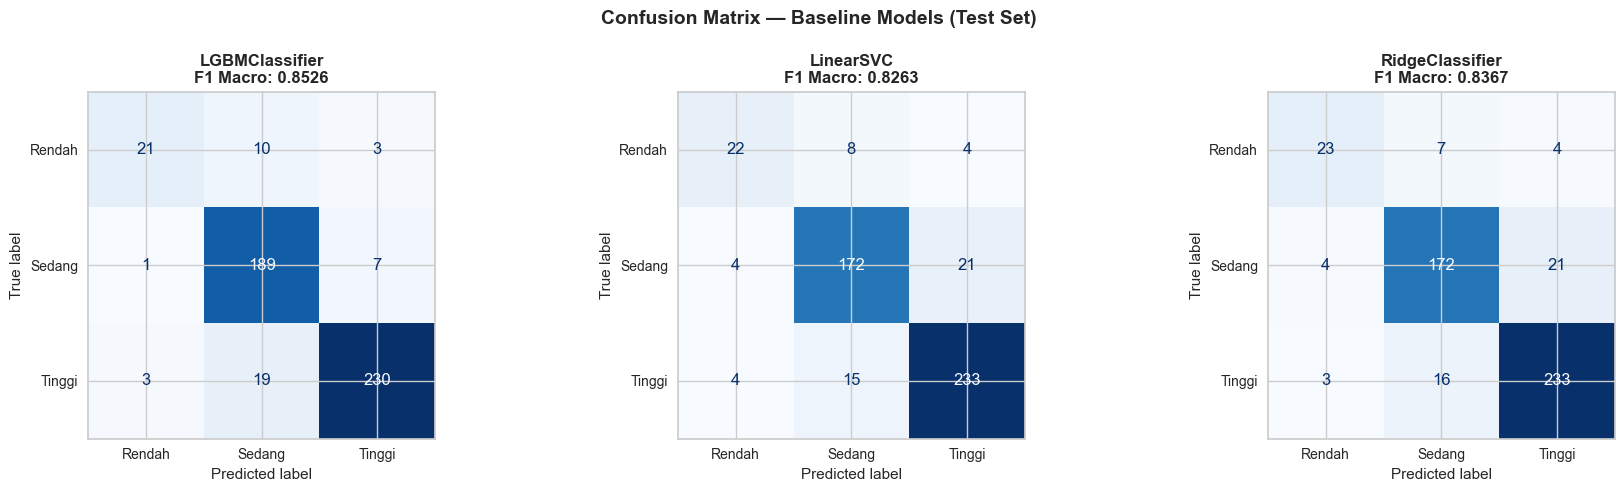

✅ Confusion matrix disimpan


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Rendah', 'Sedang', 'Tinggi']

for ax, (model_name, res) in zip(axes, baseline_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name}\nF1 Macro: {res["f1_macro"]:.4f}', fontweight='bold')

plt.suptitle('Confusion Matrix — Baseline Models (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_DIR / '10_confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix disimpan")


In [18]:
# ============================================================
# PILIH MODEL TERBAIK
# ============================================================

ranking = sorted(
    baseline_results.items(),
    key=lambda x: x[1]["f1_macro"],
    reverse=True
)

best_model_name = ranking[0][0]

print(f"🏆 Model terbaik: {best_model_name}")

🏆 Model terbaik: LGBMClassifier


## 6. Hyperparameter Tuning dengan Optuna

Model terbaik dari baseline akan di-tuning menggunakan Optuna
(Bayesian optimization) untuk mencari hyperparameter optimal.


In [19]:
# ============================================================
# OPTUNA TUNING
# ============================================================

print(f"Model tuning: {best_model_name}")


def objective(trial):

    # ========================================================
    # LIGHTGBM
    # ========================================================

    if best_model_name == "LGBMClassifier":

        params = {

            "n_estimators": trial.suggest_int(
                "n_estimators",
                100,
                500
            ),

            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.01,
                0.2,
                log=True
            ),

            "max_depth": trial.suggest_int(
                "max_depth",
                3,
                15
            ),

            "num_leaves": trial.suggest_int(
                "num_leaves",
                20,
                150
            ),

            "subsample": trial.suggest_float(
                "subsample",
                0.6,
                1.0
            ),

            "colsample_bytree": trial.suggest_float(
                "colsample_bytree",
                0.6,
                1.0
            ),

            "class_weight": "balanced",

            "random_state": 42,

            "n_jobs": -1
        }

        model = LGBMClassifier(**params)

    # ========================================================
    # LINEAR SVC
    # ========================================================

    elif best_model_name == "LinearSVC":

        params = {

            "C": trial.suggest_float(
                "C",
                0.001,
                100,
                log=True
            ),

            "max_iter": trial.suggest_int(
                "max_iter",
                3000,
                10000
            ),

            "class_weight": "balanced"
        }

        model = LinearSVC(**params)

    # ========================================================
    # RIDGE
    # ========================================================

    else:

        params = {

            "alpha": trial.suggest_float(
                "alpha",
                0.01,
                10.0,
                log=True
            ),

            "class_weight": "balanced"
        }

        model = RidgeClassifier(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(

        model,

        X_train,

        y_train,

        cv=cv,

        scoring='f1_macro',

        n_jobs=-1
    )

    return scores.mean()


study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

print("✅ Optuna selesai")
print(study.best_params)

Model tuning: LGBMClassifier


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Optuna selesai
{'n_estimators': 358, 'learning_rate': 0.10481113998151734, 'max_depth': 14, 'num_leaves': 43, 'subsample': 0.9047744515070834, 'colsample_bytree': 0.8076526779529808}


In [20]:
# ============================================================
# BUILD TUNED MODEL
# ============================================================

best_params = study.best_params.copy()

if best_model_name == "LGBMClassifier":

    best_params["class_weight"] = "balanced"

    best_params["random_state"] = 42

    best_params["n_jobs"] = -1

    tuned_model = LGBMClassifier(
        **best_params
    )

elif best_model_name == "LinearSVC":

    best_params["class_weight"] = "balanced"

    tuned_model = LinearSVC(
        **best_params
    )

else:

    best_params["class_weight"] = "balanced"

    best_params["random_state"] = 42

    tuned_model = RidgeClassifier(
        **best_params
    )

print("✅ Tuned model siap")

✅ Tuned model siap


In [21]:
# ============================================================
# TRAIN FINAL MODEL
# ============================================================

with mlflow.start_run(
    run_name=f"tuned_{best_model_name}"
):

    tuned_model.fit(
        X_train,
        y_train
    )

    y_pred_tuned = tuned_model.predict(
        X_test
    )

    tuned_metrics = {

        "accuracy": accuracy_score(
            y_test,
            y_pred_tuned
        ),

        "f1_macro": f1_score(
            y_test,
            y_pred_tuned,
            average='macro'
        ),

        "f1_weighted": f1_score(
            y_test,
            y_pred_tuned,
            average='weighted'
        ),

        "precision_macro": precision_score(
            y_test,
            y_pred_tuned,
            average='macro',
            zero_division=0
        ),

        "recall_macro": recall_score(
            y_test,
            y_pred_tuned,
            average='macro',
            zero_division=0
        ),
    }

    mlflow.log_params(best_params)

    mlflow.log_metrics(tuned_metrics)

    mlflow.sklearn.log_model(
        tuned_model,
        artifact_path="model"
    )

    tuned_run_id = mlflow.active_run().info.run_id

print("✅ Final training selesai")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.215390 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 125152
[LightGBM] [Info] Number of data points in the train set: 3288, number of used features: 5323
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

2026/05/14 10:53:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 10:53:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Final training selesai


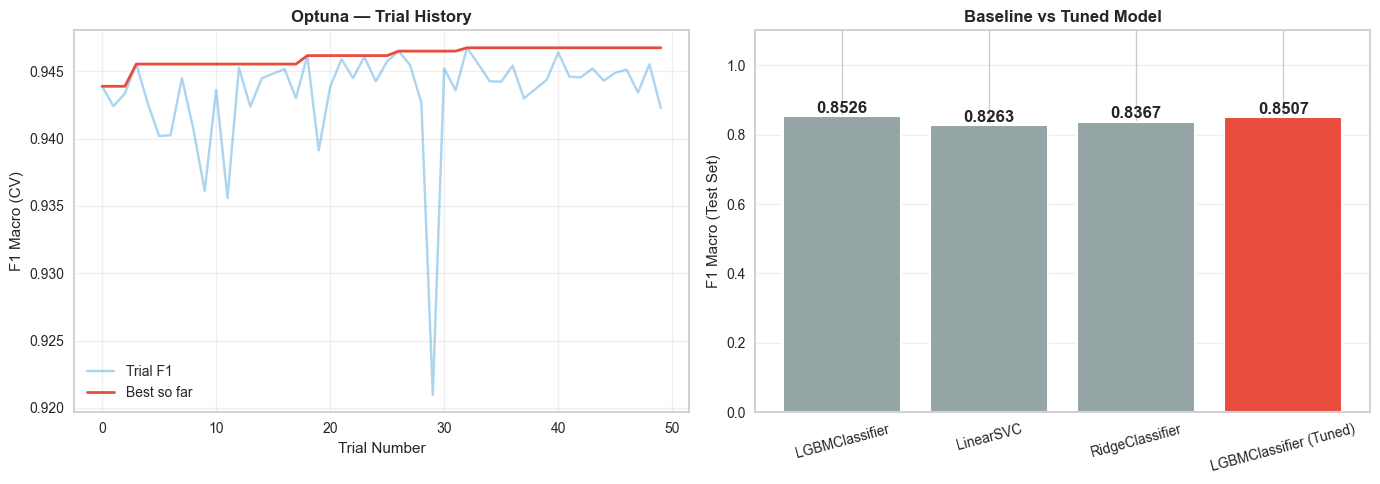

✅ Plot Optuna disimpan


In [22]:
# ── Visualisasi Optuna ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial history
trial_numbers = [t.number for t in study.trials]
trial_values  = [t.value if t.value else 0 for t in study.trials]
best_so_far   = [max(trial_values[:i+1]) for i in range(len(trial_values))]

axes[0].plot(trial_numbers, trial_values, alpha=0.4, color='#3498db', label='Trial F1')
axes[0].plot(trial_numbers, best_so_far,  color='#e74c3c', linewidth=2, label='Best so far')
axes[0].set_title('Optuna — Trial History', fontweight='bold')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('F1 Macro (CV)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Perbandingan baseline vs tuned
all_model_names = list(baseline_results.keys()) + [f"{best_model_name} (Tuned)"]
all_f1_macro    = [baseline_results[m]['f1_macro'] for m in baseline_results] + [tuned_metrics['f1_macro']]
colors_bar      = ['#95a5a6'] * len(baseline_results) + ['#e74c3c']

bars = axes[1].bar(all_model_names, all_f1_macro, color=colors_bar, edgecolor='white', linewidth=1.5)
axes[1].set_title('Baseline vs Tuned Model', fontweight='bold')
axes[1].set_ylabel('F1 Macro (Test Set)')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, all_f1_macro):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(DOCS_DIR / '11_optuna_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot Optuna disimpan")


## 7. Evaluasi Final — Model Terbaik

In [25]:
# ── Classification Report ─────────────────────────────────────
print("="*60)
print(f"  EVALUASI FINAL: {best_model_name} (Tuned)")
print("="*60)
print()
print(classification_report(y_test, y_pred_tuned,
                             target_names=['Rendah', 'Sedang', 'Tinggi']))


  EVALUASI FINAL: LGBMClassifier (Tuned)

              precision    recall  f1-score   support

      Rendah       0.81      0.62      0.70        34
      Sedang       0.88      0.95      0.91       197
      Tinggi       0.95      0.92      0.94       252

    accuracy                           0.91       483
   macro avg       0.88      0.83      0.85       483
weighted avg       0.91      0.91      0.91       483



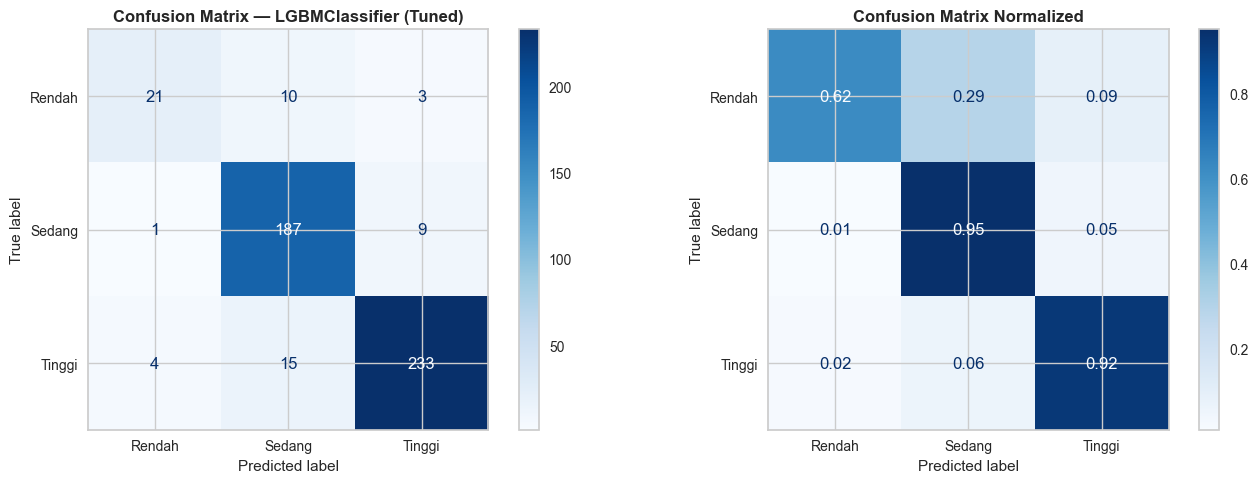

✅ Confusion matrix final disimpan


In [26]:
# ── Confusion Matrix Final ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Rendah', 'Sedang', 'Tinggi']

cm = confusion_matrix(y_test, y_pred_tuned, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=axes[0], cmap='Blues', colorbar=True)
axes[0].set_title(f'Confusion Matrix — {best_model_name} (Tuned)', fontweight='bold')

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(confusion_matrix=np.round(cm_norm, 2), display_labels=labels)
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=True)
axes[1].set_title(f'Confusion Matrix Normalized', fontweight='bold')

plt.tight_layout()
plt.savefig(DOCS_DIR / '12_confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix final disimpan")


In [27]:
# ── Ringkasan semua eksperimen ────────────────────────────────
print("\n=== RINGKASAN SEMUA EKSPERIMEN ===")
print(f"{'Model':<35} {'F1 Macro':>10} {'Accuracy':>10} {'F1 Weighted':>12}")
print("-" * 70)

for name, res in baseline_results.items():
    marker = " 🏆" if name == best_model_name else ""
    print(f"{'[Baseline] ' + name:<35} {res['f1_macro']:>10.4f} {res['accuracy']:>10.4f} {res['f1_weighted']:>12.4f}{marker}")

print(f"{'[Tuned] ' + best_model_name:<35} {tuned_metrics['f1_macro']:>10.4f} {tuned_metrics['accuracy']:>10.4f} {tuned_metrics['f1_weighted']:>12.4f} ✅ FINAL")
print()
improvement = tuned_metrics['f1_macro'] - baseline_results[best_model_name]['f1_macro']
print(f"Improvement setelah tuning: +{improvement:.4f} F1 Macro")
print(f"\nCek semua run di: http://127.0.0.1:5000")



=== RINGKASAN SEMUA EKSPERIMEN ===
Model                                 F1 Macro   Accuracy  F1 Weighted
----------------------------------------------------------------------
[Baseline] LGBMClassifier               0.8526     0.9110       0.9094 🏆
[Baseline] LinearSVC                    0.8263     0.8841       0.8830
[Baseline] RidgeClassifier              0.8367     0.8861       0.8852
[Tuned] LGBMClassifier                  0.8507     0.9130       0.9114 ✅ FINAL

Improvement setelah tuning: +-0.0019 F1 Macro

Cek semua run di: http://127.0.0.1:5000


## 8. Simpan Model Final

In [28]:
# ── Simpan model dan vectorizer ───────────────────────────────
model_path      = MODEL_DIR / "model_final.pkl"
vectorizer_path = MODEL_DIR / "vectorizer.pkl"

joblib.dump(tuned_model,  model_path)
joblib.dump(vectorizer,   vectorizer_path)

print(f"✅ Model disimpan       : {model_path}")
print(f"✅ Vectorizer disimpan  : {vectorizer_path}")
print()

# ── Simpan metadata model ──────────────────────────────────────
import json
metadata = {
    "model_name"    : best_model_name,
    "model_type"    : type(tuned_model).__name__,
    "mlflow_run_id" : tuned_run_id,
    "params"        : best_params,
    "metrics"       : tuned_metrics,
    "vectorizer"    : {
        "max_features" : vectorizer.max_features,
        "ngram_range"  : list(vectorizer.ngram_range),
        "vocabulary_size": len(vectorizer.vocabulary_),
    },
    "labels"        : ['Rendah', 'Sedang', 'Tinggi'],
    "train_size"    : len(X_train_raw),
    "test_size"     : len(X_test_raw),
}

with open(MODEL_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("✅ Metadata disimpan    :", MODEL_DIR / "model_metadata.json")
print()
print("File yang perlu di-copy ke backend:")
print(f"  backend/ml/models/model_final.pkl")
print(f"  backend/ml/models/vectorizer.pkl")
print(f"  backend/ml/models/model_metadata.json")


✅ Model disimpan       : C:\backend\ml\models\model_final.pkl
✅ Vectorizer disimpan  : C:\backend\ml\models\vectorizer.pkl

✅ Metadata disimpan    : C:\backend\ml\models\model_metadata.json

File yang perlu di-copy ke backend:
  backend/ml/models/model_final.pkl
  backend/ml/models/vectorizer.pkl
  backend/ml/models/model_metadata.json


## 9. Quick Test — Simulasi Prediksi Real-time

In [30]:
# ============================================================
# QUICK PREDICTION TEST
# ============================================================

def predict_urgensi(teks):

    X = vectorizer.transform([teks])

    pred = tuned_model.predict(X)[0]

    return pred


samples = [

    "Seorang warga ditemukan tewas dengan luka tusukan",

    "Pelaku membawa sabu dua kilogram",

    "Terjadi pembacokan di pasar",

    "Tembok sekolah dicoret cat semprot",

    "Balap liar mengganggu warga"
]

for s in samples:

    hasil = predict_urgensi(s)

    print(f"\n{s}")
    print(f"→ {hasil}")


Seorang warga ditemukan tewas dengan luka tusukan
→ Tinggi

Pelaku membawa sabu dua kilogram
→ Rendah

Terjadi pembacokan di pasar
→ Tinggi

Tembok sekolah dicoret cat semprot
→ Rendah

Balap liar mengganggu warga
→ Rendah
